# Predicting Insurance Claim Of An Individual

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
sklearn.set_config(print_changed_only=True)
np.random.seed(42)

## Cleaning and Preprocessing

In [ ]:
## Reads csv
df = pd.read_csv('../data/insurance_data.csv')
df.shape

(1340, 11)

In [ ]:
df

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87


In [ ]:
df.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [ ]:
df.dtypes

,0
index,int64
PatientID,int64
age,float64
gender,object
bmi,float64
bloodpressure,int64
diabetic,object
children,int64
smoker,object
region,object


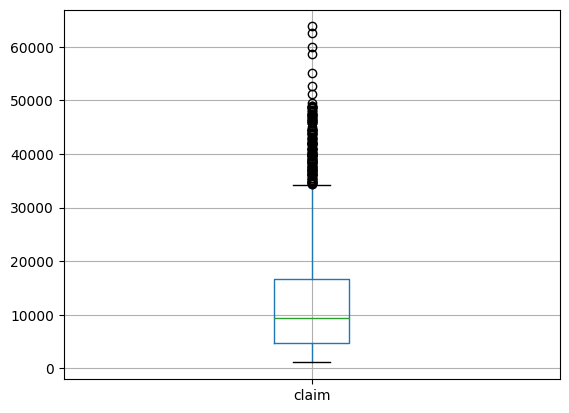

count     1340.000000
mean     13252.745642
std      12109.609288
min       1121.870000
25%       4719.685000
50%       9369.615000
75%      16604.305000
max      63770.430000
Name: claim, dtype: float64


In [ ]:
df.boxplot(column="claim")
plt.show()

print(df['claim'].describe())

In [ ]:
from scipy.stats import zscore

## Drop any missing values and unnecessary columns
df.dropna(inplace=True)
df.drop('index', axis=1, inplace=True)
df.drop('PatientID', axis=1, inplace=True)

df.shape

(1332, 9)

Converting categorical data

## Split Into Training & Test

In [ ]:
## Create X Data
df_x = df.drop(['claim'], axis=1)

## Create Y Data
df_y = df['claim']

0
1
2
3
4
5
6
7


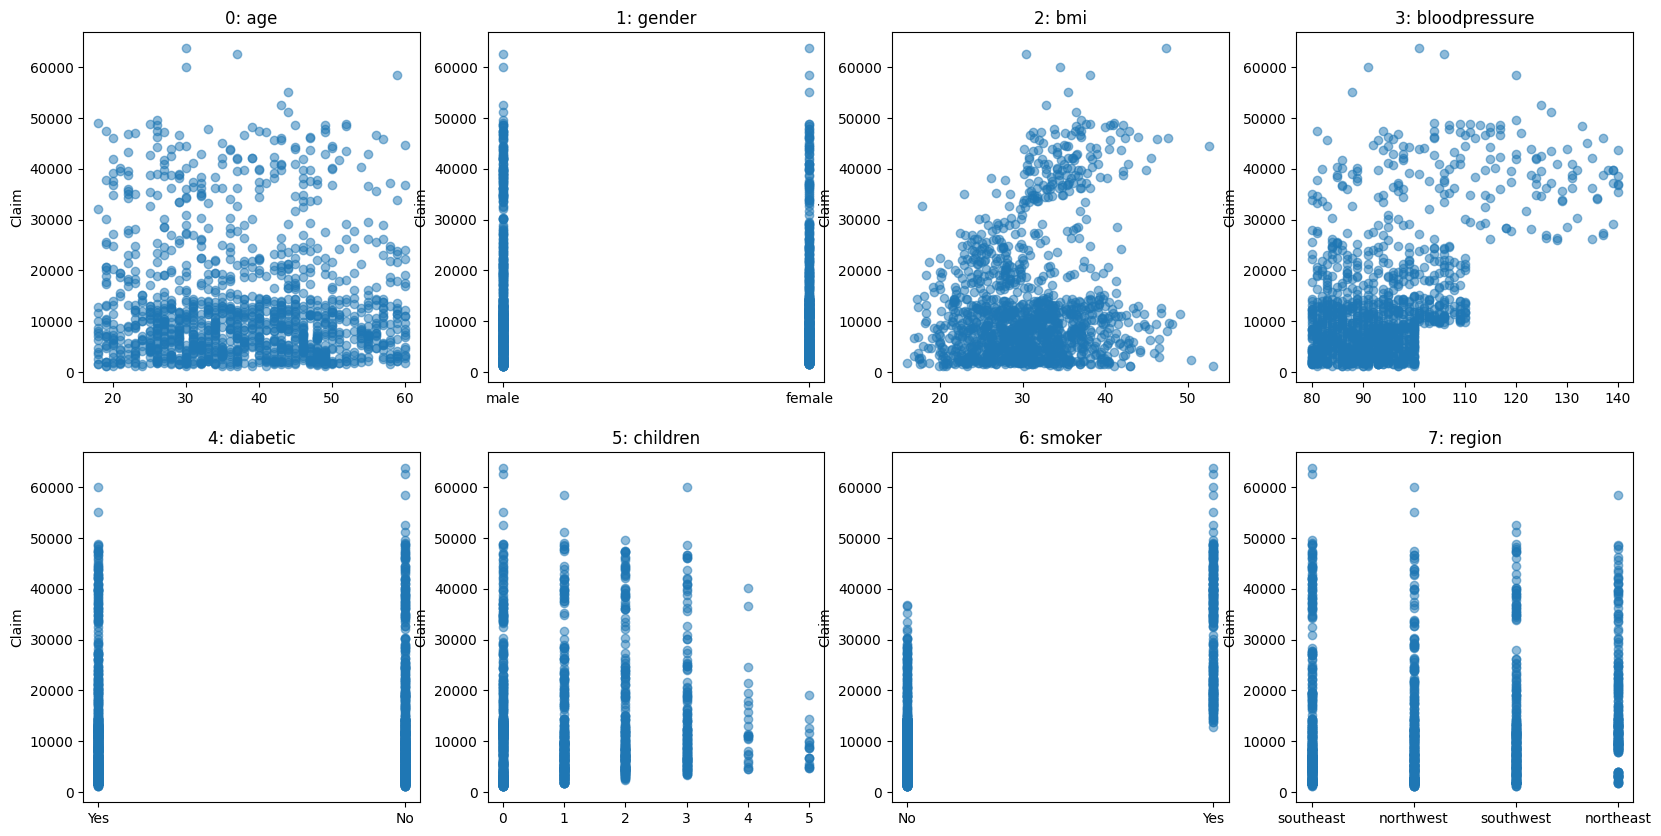

In [ ]:
## Plot Each Variable against claim

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, ax in enumerate(axes.ravel()):
    if i > 12:
        ax.set_visible(False)
        continue
    print(i)
    ax.plot(df_x.values[:, i], df_y, 'o', alpha=.5)
    ax.set_title("{}: {}".format(i, df_x.columns[i]))
    ax.set_ylabel("Claim")

In [ ]:
# using pd.get_dummies to turn categorical values to true/false
data_one_hot = pd.get_dummies(df_x)

# Split data into train and test
x_train, x_test, y_train, y_test = train_test_split(data_one_hot, df_y)


In [ ]:
## Viewing Train and Test
print(x_train.value_counts())
print(y_train.value_counts())

print(x_test.value_counts())
print(y_test.value_counts())

age   bmi   bloodpressure  children  gender_female  gender_male  diabetic_No  diabetic_Yes  smoker_No  smoker_Yes  region_northeast  region_northwest  region_southeast  region_southwest
18.0  25.5  99             0         False          True         False        True          True       False       True              False             False             False               1
44.0  30.6  82             0         False          True         True         False         True       False       False             True              False             False               1
      25.2  91             0         False          True         True         False         True       False       False             True              False             False               1
      27.0  100            2         False          True         False        True          True       False       False             False             True              False               1
      27.5  104            1         False        

## Linear Regression

Training accuracy:  0.6985193436453203
Testing accuracy:  0.7287038816190529
RMSE:  6311.194426912646
R-squared:  0.7287038816190529


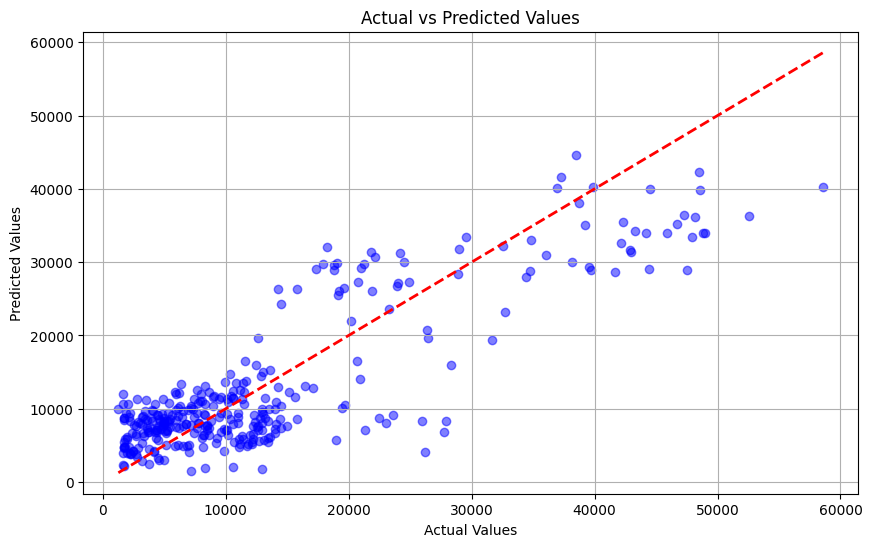

In [ ]:
from sklearn.linear_model import LinearRegression

# loading model
lr = LinearRegression()

# fitting model
lr.fit(x_train,y_train)

# printing accuracy
print("Training accuracy: ", lr.score(x_train,y_train))
print("Testing accuracy: ", lr.score(x_test,y_test))



# Evaluating accuracy using RMSE and R squared
y_pred = lr.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("RMSE: ", np.sqrt(mse))
print("R-squared: ", r2)


# Plotting actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2, linestyle='--')  # Ideal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.grid()
plt.show()

## Polynomial Regression

Training accuracy:  0.7929413347316294
Testing accuracy:  0.7884301098496544
RMSE:  5573.354911162522
R-squared:  0.7884301098496544


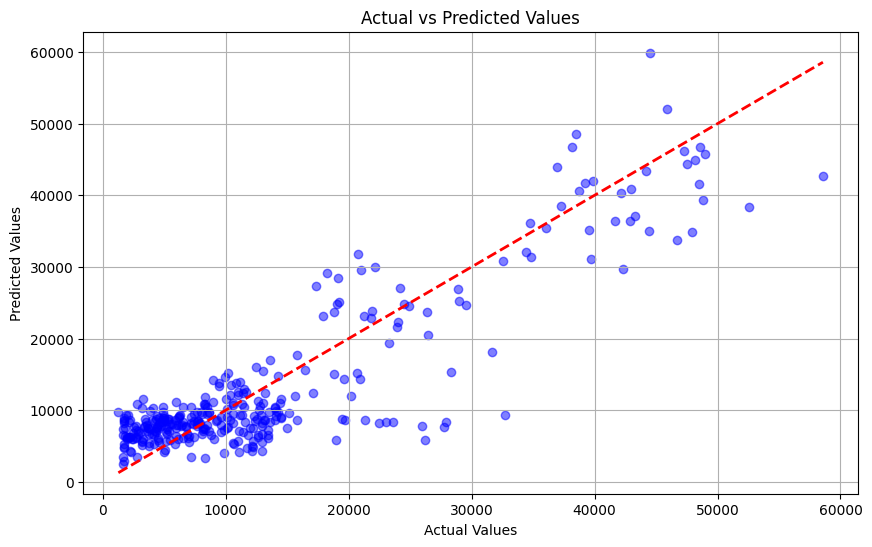

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Degree of the polynomial
degree = 2

# Transforming the features to polynomial features
poly = PolynomialFeatures(degree=degree)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

# Loading and fitting the polynomial regression model
lr = LinearRegression()
lr.fit(x_train_poly, y_train)

# Printing accuracy
print("Training accuracy: ", lr.score(x_train_poly, y_train))
print("Testing accuracy: ", lr.score(x_test_poly, y_test))

# Evaluating accuracy using RMSE and R-squared
y_pred = lr.predict(x_test_poly)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("RMSE: ", np.sqrt(mse))
print("R-squared: ", r2)


# Plotting actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2, linestyle='--')  # Ideal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.grid()
plt.show()

## Decision Tree



Best parameters: {'criterion': 'squared_error', 'max_depth': 3, 'splitter': 'best'}
RMSE:  4934.215301589681
R-squared:  0.8341724621757983


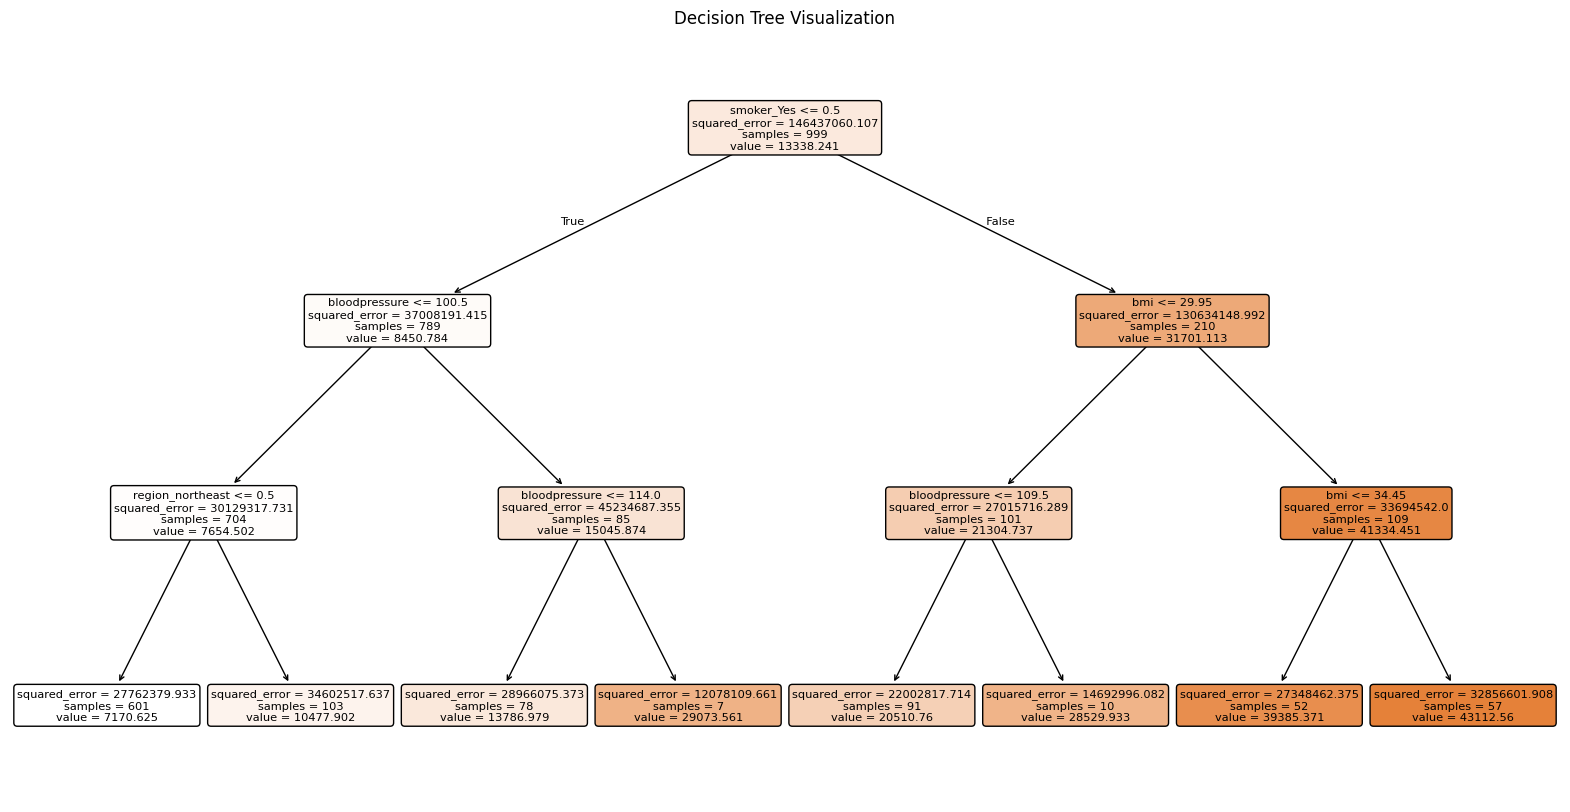

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

param_grid = {
    "criterion": ['squared_error', 'absolute_error'],
    "splitter": ['random','best'],
    "max_depth": [3,4,5,6,7,8],
}

dt = DecisionTreeRegressor()

grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=10)
grid_search.fit(x_train, y_train)

print("Best parameters:", grid_search.best_params_)

# Reinitialize the Decision Tree with the best parameters
dt = DecisionTreeRegressor(criterion=grid_search.best_params_['criterion'],
                           splitter=grid_search.best_params_['splitter'],
                           max_depth=grid_search.best_params_['max_depth'])

dt.fit(x_train, y_train)

# Evaluating accuracy using RMSE and R-squared
y_pred = dt.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("RMSE: ", np.sqrt(mse))
print("R-squared: ", r2)


# Plotting the tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=x_train.columns,
    filled=True,
    rounded=True
)

plt.title("Decision Tree Visualization")
plt.show()


## Random Forest

Best parameters: {'bootstrap': True, 'max_depth': 5, 'n_estimators': 50}
RMSE:  4933.592483063434
R-squared:  0.8342143225074408


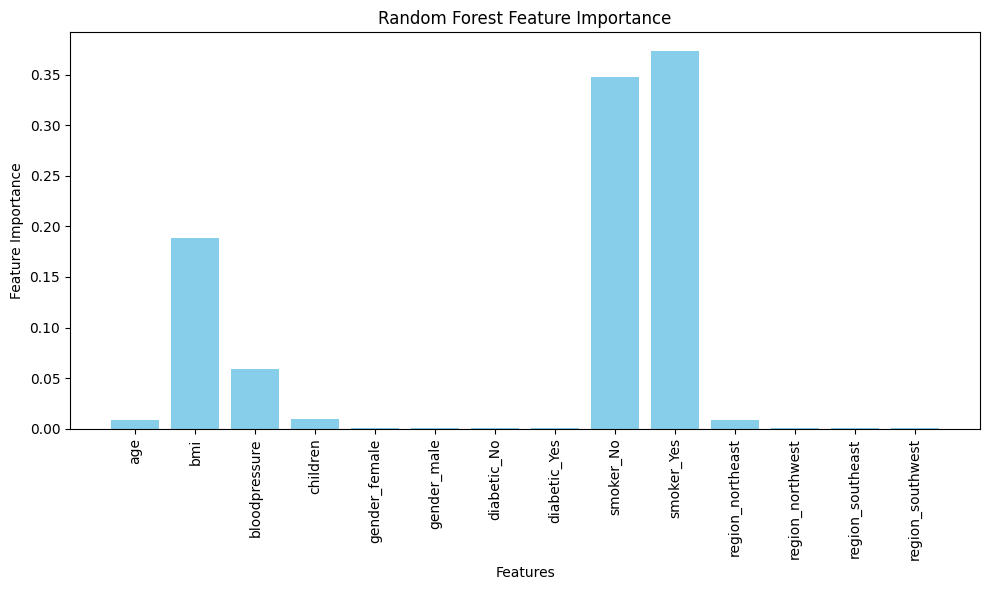

In [ ]:
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [50, 100, 150],        # Number of trees in the forest
    "max_depth": [3, 5, 8, 10, 15],       # Maximum depth of each tree
    "bootstrap": [True, False]             # Whether bootstrap samples are used
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=10)
grid_search.fit(x_train, y_train)

print("Best parameters:", grid_search.best_params_)

# Use the best parameters to create a new Random Forest model
rf = RandomForestRegressor(
    n_estimators=grid_search.best_params_["n_estimators"],
    max_depth=grid_search.best_params_["max_depth"],
    bootstrap=grid_search.best_params_["bootstrap"],
    random_state=42)

rf.fit(x_train, y_train)

# Evaluating accuracy using RMSE and R-squared
y_pred = rf.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("RMSE: ", np.sqrt(mse))
print("R-squared: ", r2)

# Feature Importance Visualization
plt.figure(figsize=(10, 6))
plt.bar(x_train.columns, rf.feature_importances_, color='skyblue')
plt.xticks(rotation=90)
plt.ylabel('Feature Importance')
plt.xlabel('Features')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

## K-Nearest Neighbors

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 31]
}

knn = KNeighborsRegressor()

# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=10)
grid_search.fit(x_train, y_train)

# Get the best parameters and model
best_params = grid_search.best_params_

print("Best Parameters: ", best_params['n_neighbors'])

knn = KNeighborsRegressor(n_neighbors=best_params['n_neighbors'])

# Fitting the model
knn.fit(x_train, y_train)


# Evaluating accuracy using RMSE and R-squared
y_pred = knn.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("RMSE: ", np.sqrt(mse))
print("R-squared: ", r2)

Best Parameters:  31
RMSE:  9652.62132609072
R-squared:  0.36538402667725633


## Support Vector Machines (SVM)

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

## Hypertuning C and epsilon paraters
param_grid = {
    'C': [0.1, 1, 10, 100, 1000, 10000, 100000, 10000000],
    'epsilon': [0.01, 0.1, 10, 100]
}

grid_search = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=10)
grid_search.fit(x_train, y_train)
print("Best parameters:", grid_search.best_params_)


# Loading the SVR model
svr = SVR(kernel='rbf', C= grid_search.best_params_['C'],
                        epsilon=grid_search.best_params_['epsilon'])

# Fitting the model
svr.fit(x_train, y_train)

# Evaluating accuracy using RMSE and R-squared
y_pred = svr.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("RMSE: ", np.sqrt(mse))
print("R-squared: ", r2)

Best parameters: {'C': 10000000, 'epsilon': 100}
RMSE:  5902.570899672546
R-squared:  0.7626971873713053


## Gradient Boosting Regression

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 4, 5],
}

gbr = GradientBoostingRegressor(random_state=42)

# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid, cv=10)
grid_search.fit(x_train, y_train)
print("Best parameters:", grid_search.best_params_)

gbr = GradientBoostingRegressor(
    n_estimators=grid_search.best_params_["n_estimators"],
    learning_rate=grid_search.best_params_["learning_rate"],
    max_depth=grid_search.best_params_["max_depth"],
    random_state=42
).fit(x_train, y_train)

# Evaluating accuracy using RMSE and R-squared
y_pred = gbr.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("RMSE: ", np.sqrt(mse))
print("R-squared: ", r2)

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
RMSE:  4882.914703773812
R-squared:  0.8376027252578475


## Neural Network

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "learning_rate": ['constant', 'adaptive'],
    "max_iter": [500, 750, 1000]
}

mlp = MLPRegressor(random_state=42)

# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(estimator=mlp, param_grid=param_grid, cv=10)
grid_search.fit(x_train, y_train)
print("Best parameters:", grid_search.best_params_)

# Build the final model using the best parameters
mlp = MLPRegressor(
    learning_rate=grid_search.best_params_["learning_rate"],
    max_iter=grid_search.best_params_["max_iter"],
    random_state=42
).fit(x_train, y_train)

# Evaluating accuracy using RMSE and R-squared
y_pred = mlp.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("RMSE: ", np.sqrt(mse))
print("R-squared: ", r2)

Best parameters: {'learning_rate': 'constant', 'max_iter': 1000}
RMSE:  10765.609003040301
R-squared:  0.21059901103967882


## Model Comparison (test set)

| Model | RMSE ($) | R² |
|---|---:|---:|
| Gradient Boosting | 4,882.91 | 0.8376 |
| Random Forest | 4,933.59 | 0.8342 |
| Decision Tree | 4,934.22 | 0.8342 |
| Polynomial Regression | 5,573.35 | 0.7884 |
| SVR | 5,902.57 | 0.7627 |
| Linear Regression | 6,311.19 | 0.7287 |
| k-NN | 9,652.62 | 0.3654 |
| Neural Network (MLP) | 10,765.61 | 0.2106 |